<a href="https://colab.research.google.com/github/mekaviraj/ML_sem5/blob/main/dl_v_prac.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# Build a Simple Neural Network with PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
x = torch.rand(100 ,3)
y = torch.rand(100 ,1)
class simplenn(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.linear = nn.Linear(3,1)
  def forward(self , x) :
    return self.linear(x)
model = simplenn()
lossfn = nn.MSELoss()
optimizer = optim.Adam(model.parameters() , lr = 0.01)
for epoch in range(100) :
  y_pred = model(x)
  loss = lossfn(y_pred, y)
  optimizer.zero_grad() #gradient zero
  loss.backward() #compute loss again
  optimizer.step()
print("final loss")
print(loss.item())
#22


final loss
0.07270374894142151


In [8]:
# Simple Neural Network with TensorFlow

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

# simple dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])   # XOR output

# build neural network
model = Sequential([
    Dense(4, activation='relu', input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

# compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# train model
model.fit(X, y, epochs=200, verbose=0)

# test prediction
pred = model.predict(X)
print("Predictions:\n", pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predictions:
 [[0.43440744]
 [0.59466773]
 [0.48100042]
 [0.5228759 ]]


In [20]:
import numpy as np
def step(x) :
  return 1 if x >=0 else 0
def seg(x) :
  return 1/ 1+ np.exp(-x)
class perceptron :
  def __init__(self , w , b) :
    self.w = w
    self.b = b
  def forward(self , x) :
    summ = np.dot(x, self.w) + self.b
    return seg(summ)
w = np.array([1 , 1])
b = -2
andgate = perceptron(w, b)

for x in [(0,0) , (0,1) , (1,0 ) , (1,1 )] :
  print(x, "->" , andgate.forward(np.array(x)) )


(0, 0) -> 8.38905609893065
(0, 1) -> 3.718281828459045
(1, 0) -> 3.718281828459045
(1, 1) -> 2.0


In [9]:
import numpy as np

# Perceptron activation function (Step function)
def step_function(x):
    if x >= 0:
        return 1
    else:
        return 0

# Perceptron function
def perceptron(x, w, b):
    y = np.dot(x, w) + b
    return step_function(y)

# Input truth table
inputs = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

# AND gate parameters
w_and = np.array([1,1])
b_and = -1.5

print("AND Gate Truth Table")
print("X1 X2 | Output")
for x in inputs:
    print(x[0], x[1], "|", perceptron(x, w_and, b_and))

print("\n")

# OR gate parameters
w_or = np.array([1,1])
b_or = -0.5

print("OR Gate Truth Table")
print("X1 X2 | Output")
for x in inputs:
    print(x[0], x[1], "|", perceptron(x, w_or, b_or))

AND Gate Truth Table
X1 X2 | Output
0 0 | 0
0 1 | 0
1 0 | 0
1 1 | 1


OR Gate Truth Table
X1 X2 | Output
0 0 | 0
0 1 | 1
1 0 | 1
1 1 | 1


In [10]:
"""Examine the feasibility of implementing the XOR and XNOR (¬XOR) operations (Non linear data) using a single perceptron. If not possible, clearly explain the reason based on the concept of linear separabilit
"""
import numpy as np

# Step activation function
def step(x):
    return 1 if x >= 0 else 0

# Perceptron training function
def train_perceptron(X, y, epochs=10, lr=0.1):
    w = np.zeros(2)
    b = 0

    for _ in range(epochs):
        for i in range(len(X)):
            z = np.dot(X[i], w) + b
            y_pred = step(z)
            error = y[i] - y_pred
            w = w + lr * error * X[i]
            b = b + lr * error
    return w, b

# Inputs
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

# XOR outputs
y_xor = np.array([0,1,1,0])

# XNOR outputs
y_xnor = np.array([1,0,0,1])

# Train perceptron for XOR
w_xor, b_xor = train_perceptron(X, y_xor)

print("XOR Results")
for x in X:
    y_pred = step(np.dot(x, w_xor) + b_xor)
    print(x, "->", y_pred)

print("\n")

# Train perceptron for XNOR
w_xnor, b_xnor = train_perceptron(X, y_xnor)

print("XNOR Results")
for x in X:
    y_pred = step(np.dot(x, w_xnor) + b_xnor)
    print(x, "->", y_pred)

print("\nConclusion:")
print("Single perceptron cannot correctly learn XOR and XNOR because the data is not linearly separable.")

XOR Results
[0 0] -> 1
[0 1] -> 1
[1 0] -> 0
[1 1] -> 0


XNOR Results
[0 0] -> 0
[0 1] -> 0
[1 0] -> 1
[1 1] -> 1

Conclusion:
Single perceptron cannot correctly learn XOR and XNOR because the data is not linearly separable.


3


In [11]:
class Perceptron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def activate(self, x):
        net = self.bias
        for i in range(len(x)):
            net += self.weights[i] * x[i]
        return 1 if net >= 0 else 0
#XOR
# Hidden layer perceptrons
p_or  = Perceptron([1, 1], -0.5)   # OR gate
p_and = Perceptron([1, 1], -1.5)   # AND gate

# Output perceptron
p_xor = Perceptron([1, -1], -0.5)
print("XOR Output:")
inputs = [(0,0), (0,1), (1,0), (1,1)]

for x in inputs:
    h1 = p_or.activate(x)
    h2 = p_and.activate(x)
    output = p_xor.activate([h1, h2])
    print(x, "->", output)

#XNOR
# NOT perceptron
p_not = Perceptron([-1], 0.5)

print("\nXNOR Output:")

for x in inputs:
    h1 = p_or.activate(x)
    h2 = p_and.activate(x)
    xor_out = p_xor.activate([h1, h2])
    xnor_out = p_not.activate([xor_out])
    print(x, "->", xnor_out)


XOR Output:
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0

XNOR Output:
(0, 0) -> 1
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


In [12]:
class Perceptron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def activate(self, x):
        net = self.bias
        for i in range(len(x)):
            net += self.weights[i] * x[i]
        return 1 if net >= 0 else 0
# Same perceptron
p = Perceptron(weights=[1, 1], bias=-1.5)

inputs = [
    [1, 0.49],   # slightly below threshold
    [1, 0.50],   # exactly at threshold
    [1, 0.51]    # slightly above threshold
]

print("Harsh Thresholding Demonstration:\n")

for x in inputs:
    output = p.activate(x)
    print("Input:", x, "Output:", output)



Harsh Thresholding Demonstration:

Input: [1, 0.49] Output: 0
Input: [1, 0.5] Output: 1
Input: [1, 0.51] Output: 1


In [13]:
import pandas as pd
import numpy as np

# load dataset
data = pd.read_csv("movies.csv")

X = data[['MattDamon','Thriller','Nolan','Rating']].values
y = data['Like'].values

# activation function
def step(x):
    return 1 if x >= 0 else 0


# i) MP Perceptron (no weights, no bias)
print("MP Perceptron (no weights, no bias)")
for x in X:
    output = step(sum(x))
    print(x, "->", output)


# ii) Perceptron (with weights)
print("\nPerceptron with weights")

w = np.zeros(X.shape[1])
lr = 0.1

for epoch in range(10):
    for i in range(len(X)):
        y_pred = step(np.dot(X[i], w))
        error = y[i] - y_pred
        w = w + lr * error * X[i]

print("Final weights:", w)


# iii) Perceptron (with weights and bias)
print("\nPerceptron with weights and bias")

w = np.zeros(X.shape[1])
b = 0
lr = 0.1

for epoch in range(10):
    for i in range(len(X)):
        y_pred = step(np.dot(X[i], w) + b)
        error = y[i] - y_pred
        w = w + lr * error * X[i]
        b = b + lr * error

print("Final weights:", w)
print("Bias:", b)


# test with sample movie
sample = np.array([1,1,1,0.9])  # Matt Damon, Thriller, Nolan, high rating
prediction = step(np.dot(sample,w) + b)

print("\nSample movie prediction:", prediction)

FileNotFoundError: [Errno 2] No such file or directory: 'movies.csv'

In [14]:
import numpy as np
from itertools import product

# step activation
def step(x):
    return 1 if x >= 0 else 0

# perceptron training
def perceptron(X, y):
    w = [0,0]
    b = 0

    for epoch in range(20):
        error = 0
        for i in range(len(X)):
            net = w[0]*X[i][0] + w[1]*X[i][1] + b
            y_pred = step(net)

            e = y[i] - y_pred

            w[0] += e * X[i][0]
            w[1] += e * X[i][1]
            b += e

            error += abs(e)

        if error == 0:
            return True

    return False


# input combinations
X = [[0,0],[0,1],[1,0],[1,1]]

# generate 16 boolean functions
functions = list(product([0,1], repeat=4))

linear = 0
non_linear = 0

for f in functions:
    if perceptron(X,f):
        linear += 1
    else:
        non_linear += 1

print("Total Boolean functions:", len(functions))
print("Linearly separable:", linear)
print("Not linearly separable:", non_linear)

Total Boolean functions: 16
Linearly separable: 14
Not linearly separable: 2


In [15]:
class MLP_boolean_functions:
    def __init__(self, out_weights, out_bias):
        self.out_weights = out_weights
        self.out_bias = out_bias

        # Hidden layer: each neuron fires for one input
        self.hidden = [
            Perceptron([-1,  1], -0.5),   # (0,1)
            Perceptron([-1, -1],  0.5),   # (0,0)
            Perceptron([ 1, -1], -0.5),   # (1,0)
            Perceptron([ 1,  1], -1.5)    # (1,1)
        ]

    def predict(self, x):
        result = 0
        for i in range(4):
            result += self.hidden[i].activate(x) * self.out_weights[i]
        return step(result + self.out_bias)
X = [
    [0,0],
    [0,1],
    [1,0],
    [1,1]
]
print("AND")
AND = MLP_boolean_functions([0, 0, 0, 1], -0.5)
for x in X:
    print(x, "->", AND.predict(x))
print("\nOR")
OR = MLP_boolean_functions([0, 1, 1, 1], -0.5)
for x in X:
    print(x, "->", OR.predict(x))
print("\nXOR")
XOR = MLP_boolean_functions([0, 1, 1, 0], -0.5)
for x in X:
    print(x, "->", XOR.predict(x))

AND
[0, 0] -> 0
[0, 1] -> 0
[1, 0] -> 0
[1, 1] -> 1

OR
[0, 0] -> 1
[0, 1] -> 0
[1, 0] -> 1
[1, 1] -> 1

XOR
[0, 0] -> 1
[0, 1] -> 0
[1, 0] -> 1
[1, 1] -> 0


In [16]:
def step(x):
    return 1 if x >= 0 else 0


class Perceptron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def activate(self, x):
        total = self.bias
        for i in range(len(x)):
            total += self.weights[i] * x[i]
        return step(total)

class MLP_3bit:
    def __init__(self, out_weights):
        self.out_weights = out_weights
        self.out_bias = -0.5

        self.hidden = [
            Perceptron([-1,-1,-1],  0.5),  # 000
            Perceptron([-1,-1, 1], -0.5),  # 001
            Perceptron([-1, 1,-1], -0.5),  # 010
            Perceptron([-1, 1, 1], -1.5),  # 011
            Perceptron([ 1,-1,-1], -0.5),  # 100
            Perceptron([ 1,-1, 1], -1.5),  # 101
            Perceptron([ 1, 1,-1], -1.5),  # 110
            Perceptron([ 1, 1, 1], -2.5)   # 111
        ]

    def predict(self, x):
        s = 0
        for i in range(8):
            s += self.hidden[i].activate(x) * self.out_weights[i]
        return step(s + self.out_bias)
X = [
    [0,0,0],
    [0,0,1],
    [0,1,0],
    [0,1,1],
    [1,0,0],
    [1,0,1],
    [1,1,0],
    [1,1,1]
]
print("3-input AND")
AND3 = MLP_3bit([0,0,0,0,0,0,0,1])
for x in X:
    print(x, "->", AND3.predict(x))
print("\n3-input OR")
OR3 = MLP_3bit([0,1,1,1,1,1,1,1])
for x in X:
    print(x, "->", OR3.predict(x))
print("\nCustom Boolean Function")
CUSTOM = MLP_3bit([0,0,1,0,1,0,0,0])
for x in X:
    print(x, "->", CUSTOM.predict(x))


3-input AND
[0, 0, 0] -> 0
[0, 0, 1] -> 0
[0, 1, 0] -> 0
[0, 1, 1] -> 0
[1, 0, 0] -> 0
[1, 0, 1] -> 0
[1, 1, 0] -> 0
[1, 1, 1] -> 1

3-input OR
[0, 0, 0] -> 0
[0, 0, 1] -> 1
[0, 1, 0] -> 1
[0, 1, 1] -> 1
[1, 0, 0] -> 1
[1, 0, 1] -> 1
[1, 1, 0] -> 1
[1, 1, 1] -> 1

Custom Boolean Function
[0, 0, 0] -> 0
[0, 0, 1] -> 0
[0, 1, 0] -> 1
[0, 1, 1] -> 0
[1, 0, 0] -> 1
[1, 0, 1] -> 0
[1, 1, 0] -> 0
[1, 1, 1] -> 0


9 and 10

Predictions:
[[0.49521425]
 [0.50308135]
 [0.5078515 ]
 [0.51192512]]


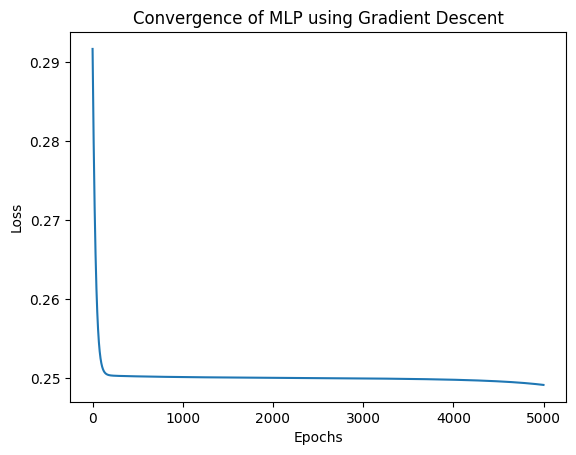

In [1]:
# Implement an MLP using the Gradient Descent algorithm, and analyze the convergence behavior and performance of the network
import numpy as np
import matplotlib.pyplot as plt

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# sigmoid activation
def sigmoid(x):
    return 1/(1+np.exp(-x))

def d_sigmoid(x):
    return x*(1-x)

# initialize weights
w1 = np.random.rand(2,2)
w2 = np.random.rand(2,1)

lr = 0.1
epochs = 5000
loss_list = []

for i in range(epochs):

    # forward propagation
    h = sigmoid(np.dot(X,w1))
    out = sigmoid(np.dot(h,w2))

    # loss
    loss = np.mean((y-out)**2)
    loss_list.append(loss)

    # backpropagation (Gradient Descent)
    d_out = (y-out)*d_sigmoid(out)
    d_h = np.dot(d_out,w2.T)*d_sigmoid(h)

    # weight updates
    w2 += lr*np.dot(h.T,d_out)
    w1 += lr*np.dot(X.T,d_h)

# predictions
print("Predictions:")
print(out)

# plot convergence
plt.plot(loss_list)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Convergence of MLP using Gradient Descent")
plt.show()

13


In [4]:
import numpy as np
from tensorflow.keras.datasets import mnist
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# reshape images (28x28 -> 784)
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

# create MLP model
model = MLPClassifier(
    hidden_layer_sizes=(128,64),   # two hidden layers
    max_iter=20,
    learning_rate_init=0.001,
    random_state=1
)

# train model
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.9768


14

In [5]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adadelta, Adam

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])

# list of optimizers
optimizers = {
    "BGD": SGD(learning_rate=0.1),
    "SGD": SGD(learning_rate=0.1),
    "MiniBatchGD": SGD(learning_rate=0.1),
    "SGD_Momentum": SGD(learning_rate=0.1, momentum=0.9),
    "SGD_Nesterov": SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
    "Adagrad": Adagrad(learning_rate=0.1),
    "RMSprop": RMSprop(learning_rate=0.01),
    "Adadelta": Adadelta(),
    "Adam": Adam(learning_rate=0.01)
}

for name,opt in optimizers.items():

    # build MLP
    model = Sequential()
    model.add(Dense(4, input_dim=2, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

    # batch size controls GD type
    if name == "BGD":
        batch = 4
    elif name == "SGD":
        batch = 1
    else:
        batch = 2

    model.fit(X,y,epochs=200,verbose=0,batch_size=batch)

    loss,acc = model.evaluate(X,y,verbose=0)

    print(name,"Accuracy:",acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


BGD Accuracy: 0.75
SGD Accuracy: 0.75
MiniBatchGD Accuracy: 0.75
SGD_Momentum Accuracy: 1.0
SGD_Nesterov Accuracy: 1.0
Adagrad Accuracy: 1.0
RMSprop Accuracy: 0.75
Adadelta Accuracy: 0.25
Adam Accuracy: 1.0


15



In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GaussianNoise
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# normalize and reshape
X_train = X_train.reshape(-1,784)/255.0
X_test = X_test.reshape(-1,784)/255.0

# MLP model with regularization
model = Sequential([
    GaussianNoise(0.1, input_shape=(784,)),        # adding noise
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)), # L2 regularization
    Dropout(0.5),                                  # dropout
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3)

# train
model.fit(X_train, y_train,
          epochs=20,
          batch_size=128,
          validation_split=0.2,
          callbacks=[early_stop])

# evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.8131 - loss: 1.0037 - val_accuracy: 0.9421 - val_loss: 0.5055
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9129 - loss: 0.5517 - val_accuracy: 0.9568 - val_loss: 0.3726
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9299 - loss: 0.4461 - val_accuracy: 0.9617 - val_loss: 0.3233
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9375 - loss: 0.3971 - val_accuracy: 0.9622 - val_loss: 0.2963
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9419 - loss: 0.3658 - val_accuracy: 0.9668 - val_loss: 0.2676
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9427 - loss: 0.3527 - val_accuracy: 0.9663 - val_loss: 0.2623
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9466 - loss: 0.3348 - val_accuracy: 0.9689 - val_loss: 0.2555
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9471 - loss: 0.3352 - val_ac

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train.reshape(-1,28,28,1))
model.fit(datagen.flow(X_train.reshape(-1,28,28,1), y_train, batch_size=128),
          epochs=20)

Epoch 1/20
 33/469 ━━━━━━━━━━━━━━━━━━━━ 1:38 225ms/step - accuracy: 0.9180 - loss: 0.2767

KeyboardInterrupt: 

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist

# load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# reshape and normalize
X_train = X_train.reshape(-1,28,28,1)/255.0
X_test = X_test.reshape(-1,28,28,1)/255.0

# build CNN model
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

# compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# train model
model.fit(X_train,y_train,epochs=5,batch_size=64)

# evaluate
loss,acc = model.evaluate(X_test,y_test)
print("Test Accuracy:",acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 54s 54ms/step - accuracy: 0.9521 - loss: 0.1613
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - accuracy: 0.9850 - loss: 0.0484
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.9892 - loss: 0.0334
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - accuracy: 0.9918 - loss: 0.0252
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 49ms/step - accuracy: 0.9941 - loss: 0.0182
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9895 - loss: 0.0331
Test Accuracy: 0.9894999861717224
